## Data visualisation
In this notebook, we explore the data downloaded from the Agroverse 1.1 motion capture dataset

In [ ]:
# --- Vector lanes (XML) overlay---
from pathlib import Path
import xml.etree.ElementTree as ET
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

MAP_DIR = Path("maps/hd_maps/map_files/") #Path to the map files
TRAIN_DIR = "data/forecasting_train_v1.1/train/data/" #Path to the dataset (training dataset)

SAMPLE_FILE = "600.csv" #Sample file, choose different to view other snippets
CSV = Path(TRAIN_DIR + SAMPLE_FILE)

# 1) Load scene
df = pd.read_csv(CSV).sort_values(["TIMESTAMP","TRACK_ID"])
city = df["CITY_NAME"].dropna().iloc[0]



In [ ]:
# 2) Pick the vector XML (MIA_10316 and PIT_10314 existed in the maps downloaded, adjust if changed)
if city == "MIA":
    XML = MAP_DIR / f"pruned_argoverse_MIA_10316_vector_map.xml"  # MIA_10316 for MIA

if city == "PIT":
    XML = MAP_DIR / f"pruned_argoverse_PIT_10314_vector_map.xml"  # MIA_10316 for MIA

assert XML.exists(), f"Missing file: {XML}"



In [84]:
# 3) Parse OSM-like vector map -> polylines
root = ET.parse(XML).getroot()
nodes = {}
for n in root.findall(".//node"):
    x = n.attrib.get("x") or n.attrib.get("lon")
    y = n.attrib.get("y") or n.attrib.get("lat")
    if x is not None and y is not None:
        nodes[n.attrib["id"]] = (float(x), float(y))

polys = []
for w in root.findall(".//way"):
    pts = []
    for nd in w.findall(".//nd"):
        ref = nd.attrib.get("ref")
        if ref in nodes: pts.append(nodes[ref])
    if len(pts) >= 2:
        polys.append(np.asarray(pts, float))


In [85]:
# 4) Find AGENT / AV tracks
agent_ids = df.loc[df["OBJECT_TYPE"] == "AGENT", "TRACK_ID"].unique()
av_ids    = df.loc[df["OBJECT_TYPE"] == "AV",    "TRACK_ID"].unique()
agent_tid = agent_ids[0] if len(agent_ids) else None
av_tid    = av_ids[0]    if len(av_ids)    else None


In [86]:
# 5) Choose a tight view around the AGENT (fallback: whole scene)
def track_bounds(tid):
    tdf = df[df["TRACK_ID"] == tid]
    return tdf["X"].min(), tdf["X"].max(), tdf["Y"].min(), tdf["Y"].max()

if agent_tid is not None:
    xmin, xmax, ymin, ymax = track_bounds(agent_tid)
    margin = 80
    xlim = (xmin - margin, xmax + margin)
    ylim = (ymin - margin, ymax + margin)
else:
    margin = 60
    xlim = (df["X"].min()-margin, df["X"].max()+margin)
    ylim = (df["Y"].min()-margin, df["Y"].max()+margin)



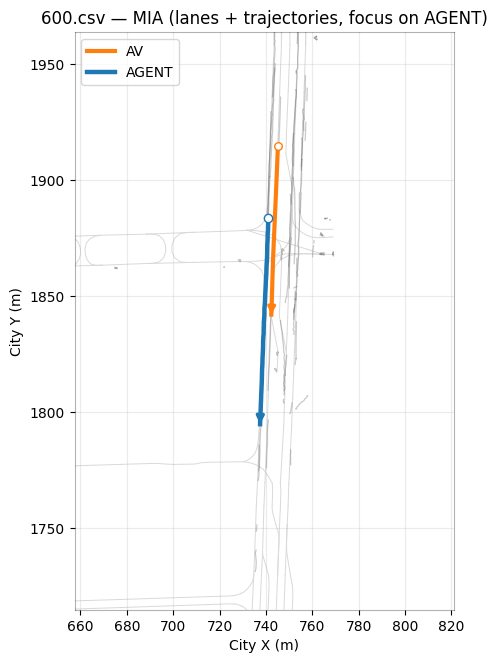

In [87]:
# 6) Plot
fig, ax = plt.subplots(figsize=(7.5, 7.5))
fig.patch.set_facecolor("white")

# Map in faint gray
for a in polys:
    ax.plot(a[:,0], a[:,1], color="0.85", linewidth=0.7, zorder=0)

# Other actors (thin & semi-transparent)
for tid, tdf in df.groupby("TRACK_ID"):
    if tid in (agent_tid, av_tid): 
        continue
    tdf = tdf.sort_values("TIMESTAMP")
    ax.plot(tdf["X"].values, tdf["Y"].values, linewidth=0.9, alpha=0.35, color="0.4", zorder=1)

# Helper to add a tiny arrow at the end of a line
def arrow_at_end(x, y, **k):
    if len(x) < 2: 
        return
    ax.annotate(
        "", xy=(x[-1], y[-1]), xytext=(x[-2], y[-2]),
        arrowprops=dict(arrowstyle="->", lw=k.get("lw", 2.5), color=k.get("color", "k")),
        zorder=k.get("zorder", 4)
    )

# AV in orange
if av_tid is not None:
    av = df[df["TRACK_ID"] == av_tid].sort_values("TIMESTAMP")
    ax.plot(av["X"], av["Y"], lw=3.0, color="tab:orange", label="AV", zorder=4)
    ax.scatter(av["X"].iloc[0], av["Y"].iloc[0], s=30, edgecolor="tab:orange", facecolor="white", zorder=5)
    arrow_at_end(av["X"].values, av["Y"].values, lw=2.5, color="tab:orange", zorder=5)

# AGENT in blue
if agent_tid is not None:
    ag = df[df["TRACK_ID"] == agent_tid].sort_values("TIMESTAMP")
    ax.plot(ag["X"], ag["Y"], lw=3.2, color="tab:blue", label="AGENT", zorder=5)
    ax.scatter(ag["X"].iloc[0], ag["Y"].iloc[0], s=36, edgecolor="tab:blue", facecolor="white", zorder=6)
    arrow_at_end(ag["X"].values, ag["Y"].values, lw=2.7, color="tab:blue", zorder=6)

# Cosmetics
ax.set_xlim(*xlim); ax.set_ylim(*ylim)
ax.set_aspect("equal", adjustable="box")
ax.grid(True, alpha=0.25)
ax.set_xlabel("City X (m)"); ax.set_ylabel("City Y (m)")
ax.set_title(f"{CSV.name} — {city} (lanes + trajectories, focus on AGENT)")
leg = ax.legend(loc="upper left", frameon=True)
for spine in ax.spines.values(): spine.set_alpha(0.3)

plt.show()